In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow import keras

2026-04-26 11:38:08.908947: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Database of fashion items
Link to the dataset: https://keras.io/datasets/#fashion-mnist-database-of-fashion-articles
Dataset of 60,000 28x28 grayscale images of 10 fashion categories, along with a test set of 10,000 images. The classes are:
The class labels are:

0. T-shirt/top
1. Trouser
2. Pullover
3. Dress
4. Coat
5. Sandal
6. Shirt
7. Sneaker
8. Bag
9. Ankle boot

### Usage
The Keras API makes it easy to load the Fashion MNIST dataset:

```python
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
```
This returns 2 tuples: the first is the training data and the second is the test data. Each tuple contains the images and their corresponding labels. The images are 28x28 NumPy arrays, and the labels are integers representing the class of each image.
The shape of the training data is (60000, 28, 28) and the shape of the test data is (10000, 28, 28). The labels are integers from 0 to 9, corresponding to the classes listed above.


In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### Data Reshape

In [5]:
X_train_full = X_train_full.reshape((60000, 28, 28, 1)) # 60,000 images, 28x28 pixels, 1 color channel (grayscale)
X_test = X_test.reshape((10000, 28, 28, 1)) # 10,000 images, 28x28 pixels, 1 color channel (grayscale)

### Data normalization

In [6]:
X_train_n = X_train_full / 255.0
X_test_n = X_test / 255.0

#### Split the data into training and validation sets
- Training data - used to train the model
- Validation data - used to evaluate the model during training and tune hyperparameters
- Test data - used to evaluate the model after training is complete

In [7]:
X_valid, X_train = X_train_n[:5000], X_train_n[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test_n

### Createing the model architecture

In [8]:
np.random.seed(42)
tf.random.set_seed(42)

In [22]:
model = keras.models.Sequential()
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), 
            strides=1, padding='valid', 
            activation='relu', input_shape=[28, 28, 1]))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(300, activation='relu'))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │     1,622,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,654,130 (6.31 MB)

 Trainable params: 1,654,130 (6.31 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [25]:
model_history = model.fit(X_train, y_train, epochs=10,
                          validation_data=(X_valid, y_valid),
                          batch_size=64)

Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.6169 - loss: 1.2160 - val_accuracy: 0.7392 - val_loss: 0.7380
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.7898 - loss: 0.5729 - val_accuracy: 0.7812 - val_loss: 0.6210
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.8165 - loss: 0.5045 - val_accuracy: 0.8068 - val_loss: 0.5525
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.8310 - loss: 0.4636 - val_accuracy: 0.8196 - val_loss: 0.5118
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.8431 - loss: 0.4347 - val_accuracy: 0.8286 - val_loss: 0.4700
Epoch 6/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.8507 - loss: 0.4120 - val_accuracy: 0.8376 - val_loss: 0.4410
Epoch 7/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.8570 - loss: 0.3935 - val_accuracy: 0.8452 - val_loss: 0.4228
Epoch 8/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.8625 - loss: 0.3774 - 

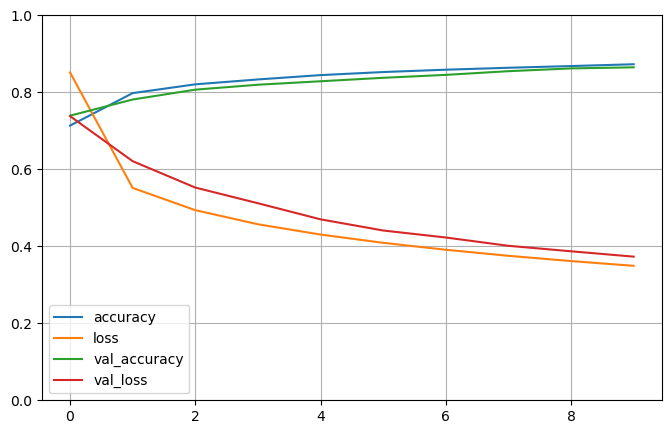

In [26]:
import pandas as pd

pd.DataFrame(model_history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [27]:
ev = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8453 - loss: 0.4103


In [28]:
ev

[0.4187251329421997, 0.8413000106811523]

In [29]:
X_new = X_test[:3]

In [30]:
y_pred = model.predict(X_new)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


array([[5.4302789e-05, 6.7894158e-05, 8.0396348e-05, 5.5537290e-05,
        4.0339364e-05, 2.3713764e-02, 8.8934394e-05, 1.4042564e-01,
        8.5126609e-03, 8.2696050e-01],
       [6.3790285e-05, 9.7471172e-07, 9.2596036e-01, 1.1720219e-05,
        5.3760648e-02, 4.7176677e-08, 2.0187670e-02, 2.3623583e-08,
        1.4732700e-05, 2.1633774e-08],
       [2.7829228e-07, 9.9997425e-01, 1.2884927e-06, 1.8986907e-06,
        2.0915031e-05, 6.8206545e-11, 1.2355599e-07, 8.9857315e-07,
        3.4624387e-07, 5.2301335e-08]], dtype=float32)

In [31]:
y_test[:3]

array([9, 2, 1], dtype=uint8)

AxesImage(shape=(28, 28))


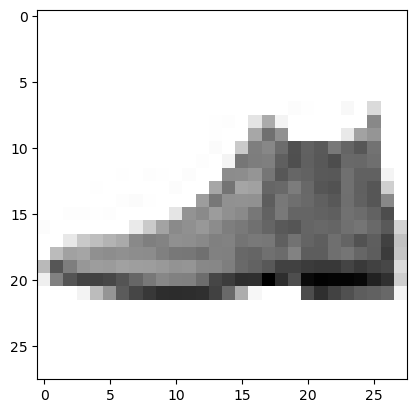

In [32]:
print(plt.imshow(X_test[0].reshape(28, 28), cmap="binary"))

In [38]:
del model
keras.backend.clear_session()

NameError: name 'model' is not defined

## Pooling vs No Pooling

In [ ]:
model_a = keras.models.Sequential()
model_a.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), 
            strides=1, padding='valid', 
            activation='relu', input_shape=[28, 28, 1]))
model_a.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model_a.add(keras.layers.Flatten())
model_a.add(keras.layers.Dense(300, activation='relu'))
model_a.add(keras.layers.Dense(100, activation='relu'))
model_a.add(keras.layers.Dense(10, activation='softmax'))

model_b = keras.models.Sequential()
model_b.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), 
            strides=1, padding='valid', 
            activation='relu', input_shape=[28, 28, 1]))
model_b.add(keras.layers.Flatten())
model_b.add(keras.layers.Dense(300, activation='relu'))
model_b.add(keras.layers.Dense(100, activation='relu'))
model_b.add(keras.layers.Dense(10, activation='softmax'))

/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model_a.summary()
model_b.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │     1,622,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,654,130 (6.31 MB)

 Trainable params: 1,654,130 (6.31 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │     6,489,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,521,330 (24.88 MB)

 Trainable params: 6,521,330 (24.88 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model_a.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])
model_b.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [37]:
model_history_a = model_a.fit(X_train, y_train, epochs=3,
                          validation_data=(X_valid, y_valid),
                          batch_size=64)
model_history_b = model_b.fit(X_train, y_train, epochs=3,
                          validation_data=(X_valid, y_valid),
                          batch_size=64)

Epoch 1/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.6076 - loss: 1.2096 - val_accuracy: 0.7298 - val_loss: 0.7315
Epoch 2/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.7986 - loss: 0.5530 - val_accuracy: 0.7900 - val_loss: 0.5837
Epoch 3/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.8245 - loss: 0.4829 - val_accuracy: 0.8124 - val_loss: 0.5229
Epoch 1/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 57s 65ms/step - accuracy: 0.6426 - loss: 1.0893 - val_accuracy: 0.7286 - val_loss: 0.7411
Epoch 2/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 57s 66ms/step - accuracy: 0.8112 - loss: 0.5162 - val_accuracy: 0.7964 - val_loss: 0.5711
Epoch 3/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 56s 65ms/step - accuracy: 0.8368 - loss: 0.4500 - val_accuracy: 0.8140 - val_loss: 0.5126


In [39]:
del model_a, model_b
keras.backend.clear_session()